In [115]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from scipy.spatial import distance
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()


1

In [116]:
def conflict(tab):
    if tab[0]==tab[1] and tab[1]==tab[2]:
        return 6
    elif tab[0]==tab[1]:
        return 3
    elif tab[0]==tab[2]:
        return 4
    return 5

def remis(tab):
    if tab.count(np.max(tab))>1:
        return 1
    else:
        return 0
    
def knn( k, xtr, ytr, x ):
    y_pred=np.zeros((len(x)),dtype=int)
    unclassified=[]
    real_index=-1
    for i in x:
        # dst - lista odległości od testowych puntków, s - jej posortowana wersja
        dst=[]
        for j in xtr:
            dst.append(distance.euclidean(i,j))
        s=np.sort(dst)
        # znalezienie indeksów kolejnych k-sąsiadów, spr ich grupy, i add to proper index in category_count
        category_count=[0,0,0]
        for l in  range(k):
             index=dst.index(s[l])
             category=ytr[index]
             category_count[category]+=1
        
        # if some categories are in remis, save index and later assign most_frequent class to it 
        real_index+=1
        if remis(category_count):
            unclassified.append(real_index)
            y_pred[real_index]=conflict(category_count)
        else:
         y_pred[real_index]=np.argmax(category_count)
    
    # print(y_pred)
    
    frequency=np.bincount(y_pred)
    most_frequent=np.argmax(frequency)
    case3=np.argmax(frequency[:2])
    case5=np.argmax(frequency[1:])+1
    if frequency[0]>=frequency[2]:
        case4=0
    else:
        case4=2
    conflict_tab=[case3,case4,case5,most_frequent]
    for i in unclassified:
        y_pred[i]=conflict_tab[y_pred[i]-3]

    return y_pred

#separate the set for teaching and testing, test_size - percentage share (example 70% for training and 30% for testing)
X_train,X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.5)

knn(3,X_train, y_train, X_test)


array([2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 1, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 2,
       1, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2,
       1, 2, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 0, 0, 0, 1, 1,
       2, 0, 0, 2, 2, 2, 2, 0, 0])

1. 2.

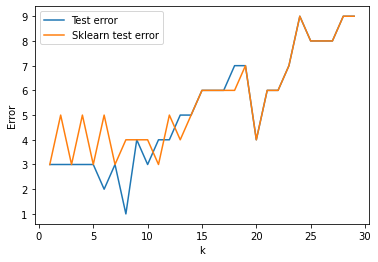

Pierwsze najlepsze k :  8
Pierwsze najlepsze k dla Skylearn :  1


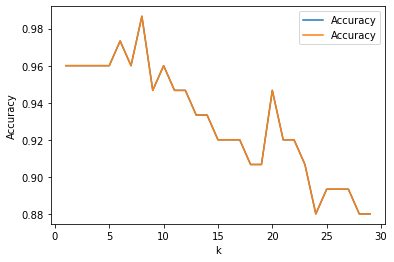

In [117]:
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train,X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.5)
k_values = range(1, 30)

l=len(y_test)
test_errors = []
test_errors2 = []
accuracy=[]
accuracy2=[]

for k in k_values:
    y_test_pred = knn(k,X_train, y_train, X_test)
    test_errors.append(np.sum(y_test_pred != y_test))
    accuracy.append((l-test_errors[-1])/l)

    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(X_train, y_train)
    y_test_pred = neigh.predict(X_test)
    test_errors2.append(np.sum(y_test_pred != y_test))
    accuracy2.append((l-test_errors[-1])/l)

plt.plot(k_values, test_errors, label='Test error')
plt.plot(k_values, test_errors2, label='Sklearn test error')
plt.xlabel('k')
plt.ylabel('Error')
plt.legend()
plt.show()

print("Pierwsze najlepsze k : ", np.argmin(test_errors) + 1)
print("Pierwsze najlepsze k dla Skylearn : ", np.argmin(test_errors2) + 1)

plt.plot(k_values, accuracy, label='Accuracy')
plt.plot(k_values, accuracy2, label='Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

To które k jest najlepsze zależy od podziału danych na testowe i treningowe, dla podziału 0.6 najczęściej były to 1,3,4,5. Ogólna tendecja jest taka że powyżej dziesięciu dokładność jest średnia, a od 20 algorytm nie powinien być używany.

3

In [118]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
clf = tree.DecisionTreeClassifier()
clf.fit(iris.data, iris.target)

DecisionTreeClassifier()

In [119]:
clf.predict(iris.data[:1, :])
clf.predict_proba(iris.data[:1, :])

array([[1., 0., 0.]])

In [120]:
from six import StringIO  
import pydot 
dot_data = StringIO() 
tree.export_graphviz(clf, out_file=dot_data) 
graph = pydot.graph_from_dot_data(dot_data.getvalue()) 
graph[0].write("iris.pdf")
# print(graph[0])

True

4

In [121]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn import tree
from sklearn.model_selection import train_test_split
from scipy.io import loadmat

from keras.datasets import mnist
 
 
# wczytywanie danych
# dane = loadmat('mnist.mat')
(train_X, train_y), (test_X, test_y) = mnist.load_data()

In [122]:

#Ex.1.Divide the data into parameters X and answer y:
 
X = train_X
y = train_y
 
# Standardization
for i in range(X.shape[0]):
    X[i,:] = X[i,:]/np.std(X[i,:])
 
# Convert digit 10 -> 0 (error in the dataset)    
y[np.where(y==10)]=0
 
# the height and width of the picture with the number
h = 28
w = 28
 
# Ex 2. Please display the number of digits and the number of pixels per image
print(X.shape)
print(y.shape)


(60000, 28, 28)
(60000,)


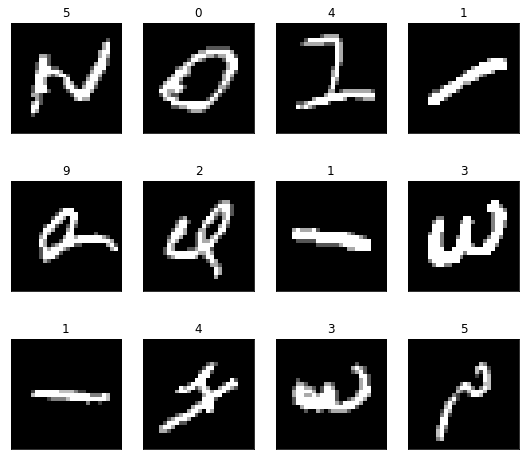

In [123]:
h = 28
w = 28

def plot_mnist(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.05)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)).T, cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

plot_mnist(X[:12],y[:12],h=h,w=w)

In [125]:
DEPTH = 10
clf = tree.DecisionTreeClassifier(max_depth=DEPTH)
X = X.reshape(60000, 784)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [126]:
print(f1_score(y_test, y_pred, average=None))
print(confusion_matrix(y_test, y_pred),'\n')
import sklearn
print(sklearn.metrics.classification_report(y_test, y_pred))

[0.89059829 0.94099849 0.78830158 0.77491785 0.80174419 0.73312693
 0.84077506 0.875      0.77366255 0.74585921]
[[1563    0   40   27   10   30   41   14   37   17]
 [   1 1866   34   18   10    9   24   16   25    5]
 [  43   19 1469   58   43   26   81   26   58   46]
 [  12    9   68 1415   20  141   21   24   38   88]
 [   8    5   31   22 1379   43   30    8   18  191]
 [  31   12   39  131   23 1184   44   11   53   68]
 [  40   12   32    8   40   45 1497    5   45   10]
 [   6    7   40   24   51   13   13 1596   21  110]
 [  16   23   86   67   40   60   57    9 1316   72]
 [  11    5   19   46   89   83   19   58   45 1441]] 

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1779
           1       0.95      0.93      0.94      2008
           2       0.79      0.79      0.79      1869
           3       0.78      0.77      0.77      1836
           4       0.81      0.79      0.80      1735
           5       0.72      